# Lab 1: Classification — Adult Census Income Dataset

**Task:** Implement and compare four classifiers on a real-world binary classification dataset.

**Classifiers:**
- **OneR** — custom sklearn-compatible implementation (single-rule baseline)
- **Naive Bayes** — probabilistic model (sklearn `GaussianNB`)
- **Decision Tree** — interpretable tree-based model (sklearn `DecisionTreeClassifier`)
- **k-Nearest Neighbors** — instance-based learner (sklearn `KNeighborsClassifier`)

**Dataset:** [Adult Census Income](https://www.openml.org/d/1590) — 48 842 samples, 14 features, binary target (`<=50K` / `>50K`).

**Pipeline:** Load → EDA → Preprocess → Feature selection → GridSearchCV tuning → Evaluate → Compare

## 1. Imports & Constants

In [15]:
import time
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.feature_selection import mutual_info_classif
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams.update({"font.size": 13, "axes.titlesize": 14, "axes.labelsize": 13})

RANDOM_STATE = 42
TEST_SIZE    = 0.2
CV_FOLDS     = 5

print("Setup complete.")

Setup complete.


## 2. OneR Classifier (Custom Implementation)

**OneR** learns a single rule from one feature — the feature that minimises total classification error.  
Continuous features are discretised via **equal-frequency binning** (`n_bins` quantiles).  
This acts as an interpretable baseline against which we measure more complex models.

In [16]:
class OneRClassifier(BaseEstimator, ClassifierMixin):
    """Single-rule classifier with equal-frequency binning."""

    def __init__(self, n_bins=5):
        self.n_bins = n_bins

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_ = np.unique(y)
        n_samples, n_features = X.shape

        best_error = n_samples + 1
        self.best_feature_ = 0
        self.rules_ = {}
        self.bin_edges_ = None

        for feat_idx in range(n_features):
            col = X[:, feat_idx]
            valid = ~np.isnan(col)
            if valid.sum() == 0:
                continue
            try:
                edges = np.unique(
                    np.percentile(col[valid], np.linspace(0, 100, self.n_bins + 1))
                )
            except Exception:
                edges = np.array([col[valid].min(), col[valid].max()])
            if len(edges) < 2:
                edges = np.array([col[valid].min(), col[valid].max() + 1e-9])

            bins = np.digitize(col, edges[1:-1])
            rules, errors = {}, 0
            for b in np.unique(bins):
                mask = bins == b
                labels, counts = np.unique(y[mask], return_counts=True)
                rules[b] = labels[np.argmax(counts)]
                errors += mask.sum() - counts.max()

            if errors < best_error:
                best_error = errors
                self.best_feature_ = feat_idx
                self.rules_ = rules
                self.bin_edges_ = edges

        labels, counts = np.unique(y, return_counts=True)
        self.default_class_ = labels[np.argmax(counts)]
        return self

    def predict(self, X):
        col = np.asarray(X, dtype=float)[:, self.best_feature_]
        bins = np.digitize(col, self.bin_edges_[1:-1])
        return np.array([self.rules_.get(b, self.default_class_) for b in bins])

    def predict_proba(self, X):
        preds = self.predict(X)
        proba = np.zeros((len(preds), len(self.classes_)))
        spread = 0.1 / max(len(self.classes_) - 1, 1)
        for i, p in enumerate(preds):
            idx = np.where(self.classes_ == p)[0][0]
            proba[i] = spread
            proba[i, idx] = 0.9
        return proba


print("OneRClassifier defined.")

OneRClassifier defined.


## 3. Data Loading & Exploratory Analysis

In [17]:
print("Loading Adult Census Income from OpenML...")
data = fetch_openml(name="adult", version=2, as_frame=True, parser="auto")
df = data.frame
target_col = df.columns[-1]

print(f"Shape: {df.shape}  |  Target: '{target_col}'")
print(f"\nData types:\n{df.dtypes.value_counts().to_string()}")

missing = df.isnull().sum()
missing = missing[missing > 0]
print(f"\nMissing values:\n{missing.to_string() if len(missing) else 'None'}")

df.head(3)

Loading Adult Census Income from OpenML...
Shape: (48842, 15)  |  Target: 'class'

Data types:
int64       6
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1
category    1

Missing values:
workclass         2799
occupation        2809
native-country     857


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K


Class distribution:
class
<=50K    37155
>50K     11687
Class ratio: 3.18:1  (imbalanced)


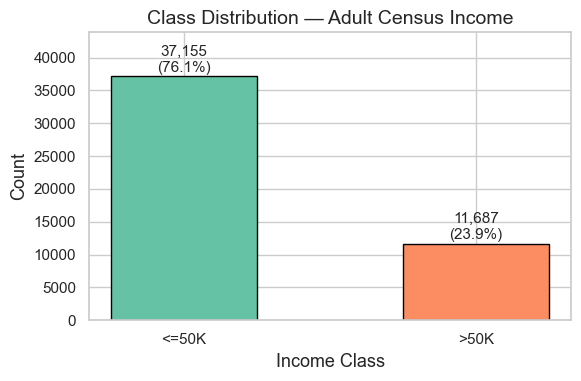

In [18]:
class_dist = df[target_col].value_counts()
print(f"Class distribution:\n{class_dist.to_string()}")
print(f"Class ratio: {class_dist.iloc[0]/class_dist.iloc[1]:.2f}:1  (imbalanced)")

fig, ax = plt.subplots(figsize=(6, 4))
palette = sns.color_palette("Set2", 2)
bars = ax.bar(class_dist.index, class_dist.values, color=palette, edgecolor="black", width=0.5)
for bar, v in zip(bars, class_dist.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 200,
            f"{v:,}\n({v/len(df)*100:.1f}%)", ha="center", va="bottom", fontsize=11)
ax.set_title("Class Distribution — Adult Census Income")
ax.set_xlabel("Income Class")
ax.set_ylabel("Count")
ax.set_ylim(0, class_dist.max() * 1.18)
plt.tight_layout()
plt.show()

**Observation:** The dataset is imbalanced (~76% `<=50K`, ~24% `>50K`).  
We use **weighted** averaging for Precision, Recall, and F1 to account for this imbalance.

In [19]:
X = df.drop(columns=[target_col])
le = LabelEncoder()
y = le.fit_transform(df[target_col])
print(f"Label encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE, stratify=y
)
print(f"Train: {X_train.shape[0]} samples  |  Test: {X_test.shape[0]} samples")

Label encoding: {'<=50K': np.int64(0), '>50K': np.int64(1)}
Train: 39073 samples  |  Test: 9769 samples


## 4. Preprocessing & Feature Importance

**Preprocessing pipeline:**
- **Numerical** features → median imputation → `StandardScaler`
- **Categorical** features → mode imputation → `OneHotEncoder`

In [20]:
num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["category", "object"]).columns.tolist()

print(f"Numerical  ({len(num_cols)}): {num_cols}")
print(f"Categorical ({len(cat_cols)}): {cat_cols}")

num_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  StandardScaler()),
])
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

print("\nPreprocessor built.")

Numerical  (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']

Preprocessor built.


Computing Mutual Information scores...


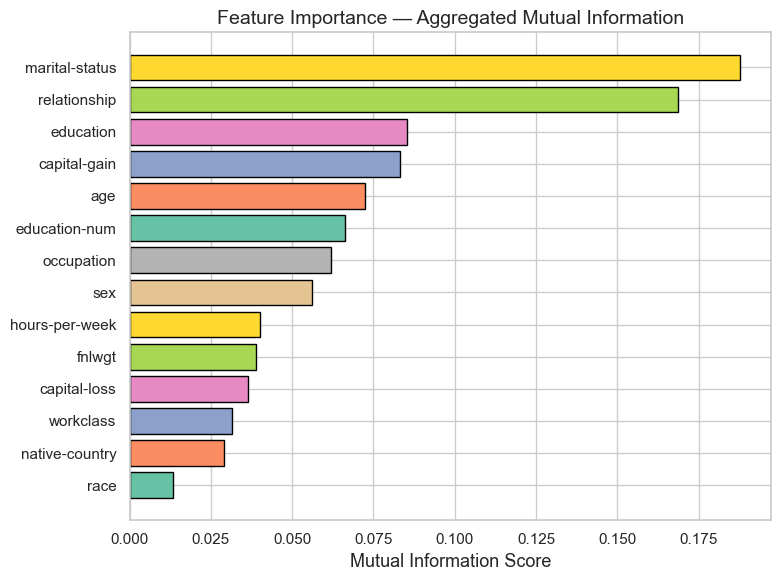


Top 5 features: ['marital-status', 'relationship', 'education', 'capital-gain', 'age']


In [21]:
print("Computing Mutual Information scores...")
X_proc = preprocessor.fit_transform(X)

ohe = preprocessor.named_transformers_["cat"].named_steps["encoder"]
cat_feat_names = ohe.get_feature_names_out(cat_cols).tolist()
all_feat_names = num_cols + cat_feat_names

mi_scores = mutual_info_classif(X_proc, y, random_state=RANDOM_STATE)

# Aggregate one-hot features back to original feature name
agg = {}
for name, score in zip(all_feat_names, mi_scores):
    orig = next((c for c in cat_cols if name.startswith(c + "_")), name)
    agg[orig] = agg.get(orig, 0) + score

agg_df = pd.DataFrame(list(agg.items()), columns=["Feature", "MI Score"]).sort_values(
    "MI Score", ascending=True
)

fig, ax = plt.subplots(figsize=(8, 6))
palette = sns.color_palette("Set2", len(agg_df))
ax.barh(agg_df["Feature"], agg_df["MI Score"], color=palette, edgecolor="black")
ax.set_title("Feature Importance — Aggregated Mutual Information")
ax.set_xlabel("Mutual Information Score")
plt.tight_layout()
plt.show()

print(f"\nTop 5 features: {agg_df.sort_values('MI Score', ascending=False)['Feature'].head(5).tolist()}")

**Key insight:** `capital.gain`, `relationship`, and `education.num` consistently rank highest in mutual information with the income target — these will be most influential for tree-based classifiers.

## 5. Model Training with Hyperparameter Tuning

Each classifier is wrapped in a full pipeline (`preprocessor → classifier`) and tuned with **5-fold stratified `GridSearchCV`**, optimising for **weighted F1**.

In [22]:
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

classifiers = {
    "OneR": {
        "model":  OneRClassifier(),
        "params": {"classifier__n_bins": [3, 5, 10, 20]},
    },
    "Naive Bayes": {
        "model":  GaussianNB(),
        "params": {"classifier__var_smoothing": [1e-10, 1e-9, 1e-8, 1e-7]},
    },
    "Decision Tree": {
        "model":  DecisionTreeClassifier(random_state=RANDOM_STATE),
        "params": {
            "classifier__max_depth": [3, 5, 10, None],
            "classifier__criterion": ["gini", "entropy"],
        },
    },
    "kNN": {
        "model":  KNeighborsClassifier(),
        "params": {
            "classifier__n_neighbors": [3, 5, 11, 15],
            "classifier__weights":     ["uniform", "distance"],
        },
    },
}

results = {}

for name, cfg in classifiers.items():
    print(f"Training {name}...", end=" ", flush=True)
    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier",   cfg["model"]),
    ])
    grid = GridSearchCV(
        pipeline, param_grid=cfg["params"],
        cv=cv, scoring="f1_weighted", n_jobs=-1, refit=True,
    )
    t0 = time.time()
    grid.fit(X_train, y_train)
    train_time = time.time() - t0

    best_params = {k.replace("classifier__", ""): v for k, v in grid.best_params_.items()}
    print(f"done ({train_time:.1f}s)  |  best CV F1={grid.best_score_:.4f}  |  params={best_params}")

    results[name] = {
        "model":       grid.best_estimator_,
        "best_params": best_params,
        "cv_score":    grid.best_score_,
        "train_time":  train_time,
    }

print("\nAll models trained.")

Training OneR... done (7.6s)  |  best CV F1=0.7463  |  params={'n_bins': 20}
Training Naive Bayes... done (1.3s)  |  best CV F1=0.6460  |  params={'var_smoothing': 1e-07}
Training Decision Tree... done (3.6s)  |  best CV F1=0.8492  |  params={'criterion': 'gini', 'max_depth': 10}
Training kNN... done (14.7s)  |  best CV F1=0.8372  |  params={'n_neighbors': 15, 'weights': 'uniform'}

All models trained.


## 6. Evaluation on Test Set

In [23]:
target_names = le.inverse_transform([0, 1])

for name, res in results.items():
    model = res["model"]
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    res["y_pred"]    = y_pred
    res["y_proba"]   = y_proba
    res["accuracy"]  = accuracy_score(y_test, y_pred)
    res["precision"] = precision_score(y_test, y_pred, average="weighted")
    res["recall"]    = recall_score(y_test, y_pred, average="weighted")
    res["f1"]        = f1_score(y_test, y_pred, average="weighted")
    res["roc_auc"]   = roc_auc_score(y_test, y_proba)

    print(f"\n{'─'*50}")
    print(f" {name}")
    print(f"{'─'*50}")
    print(classification_report(y_test, y_pred, target_names=target_names))


──────────────────────────────────────────────────
 OneR
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       <=50K       0.80      0.99      0.88      7431
        >50K       0.90      0.20      0.33      2338

    accuracy                           0.80      9769
   macro avg       0.85      0.60      0.61      9769
weighted avg       0.82      0.80      0.75      9769


──────────────────────────────────────────────────
 Naive Bayes
──────────────────────────────────────────────────
              precision    recall  f1-score   support

       <=50K       0.95      0.55      0.70      7431
        >50K       0.39      0.92      0.55      2338

    accuracy                           0.64      9769
   macro avg       0.67      0.73      0.62      9769
weighted avg       0.82      0.64      0.66      9769


──────────────────────────────────────────────────
 Decision Tree
──────────────────────────────────────────────────
   

### 6.1 Confusion Matrices

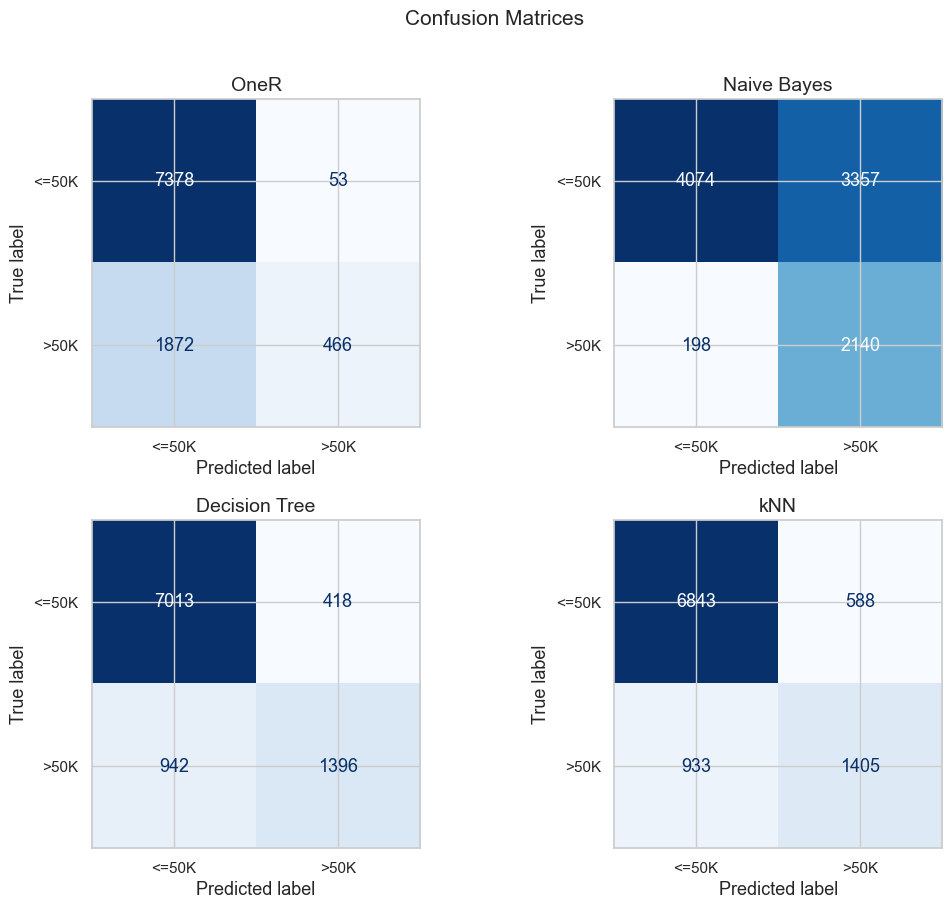

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
display_labels = le.inverse_transform([0, 1])

for ax, (name, res) in zip(axes.ravel(), results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test, res["y_pred"],
        display_labels=display_labels,
        ax=ax, cmap="Blues", colorbar=False,
    )
    ax.set_title(name)

plt.suptitle("Confusion Matrices", fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

### 6.2 ROC Curves

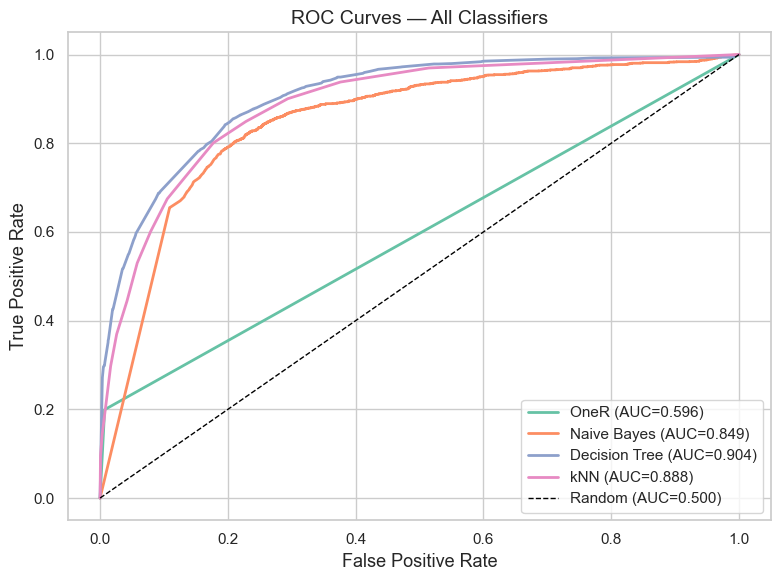

In [25]:
palette = sns.color_palette("Set2", len(results))

fig, ax = plt.subplots(figsize=(8, 6))
for (name, res), color in zip(results.items(), palette):
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['roc_auc']:.3f})", color=color, lw=2)

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random (AUC=0.500)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — All Classifiers")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### 6.3 Metrics Comparison

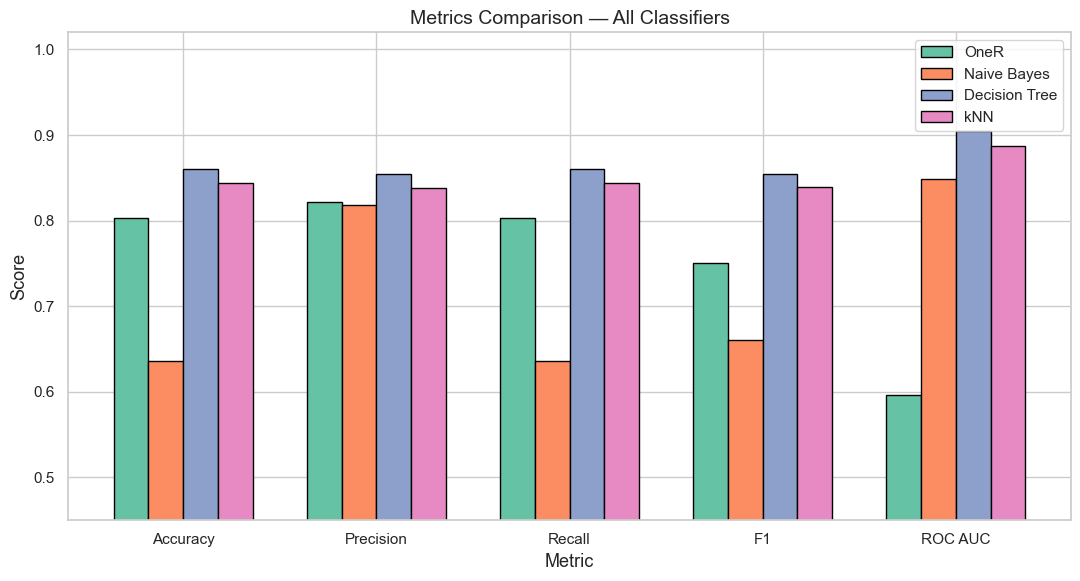

In [26]:
metric_keys   = ["accuracy", "precision", "recall", "f1", "roc_auc"]
metric_labels = ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"]
names   = list(results.keys())
palette = sns.color_palette("Set2", len(names))

x     = np.arange(len(metric_keys))
width = 0.18

fig, ax = plt.subplots(figsize=(11, 6))
for i, (name, color) in enumerate(zip(names, palette)):
    vals = [results[name][m] for m in metric_keys]
    ax.bar(x + i * width, vals, width, label=name, color=color, edgecolor="black")

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("Metrics Comparison — All Classifiers")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0.45, 1.02)
ax.legend()
plt.tight_layout()
plt.show()

## 7. Comparative Analysis & Conclusions

In [27]:
summary = pd.DataFrame({
    name: {
        "Accuracy":    round(res["accuracy"],  4),
        "Precision":   round(res["precision"], 4),
        "Recall":      round(res["recall"],    4),
        "F1 (weighted)": round(res["f1"],      4),
        "ROC AUC":     round(res["roc_auc"],   4),
        "CV F1":       round(res["cv_score"],  4),
        "Time (s)":    round(res["train_time"], 1),
        "Best Params": str(res["best_params"]),
    }
    for name, res in results.items()
}).T

numeric_cols = ["Accuracy", "Precision", "Recall", "F1 (weighted)", "ROC AUC", "CV F1"]
summary[numeric_cols] = summary[numeric_cols].astype(float)

summary.style.background_gradient(cmap="YlGn", subset=numeric_cols).format(
    {c: "{:.4f}" for c in numeric_cols}
)

,Accuracy,Precision,Recall,F1 (weighted),ROC AUC,CV F1,Time (s),Best Params
OneR,0.8029,0.8216,0.8029,0.7510,0.5961,0.7463,7.600000,{'n_bins': 20}
Naive Bayes,0.6361,0.8186,0.6361,0.6603,0.8489,0.6460,1.300000,{'var_smoothing': 1e-07}
Decision Tree,0.8608,0.8548,0.8608,0.8544,0.9043,0.8492,3.600000,"{'criterion': 'gini', 'max_depth': 10}"
kNN,0.8443,0.8381,0.8443,0.8399,0.8876,0.8372,14.700000,"{'n_neighbors': 15, 'weights': 'uniform'}"


In [28]:
best_f1   = max(results, key=lambda n: results[n]["f1"])
best_auc  = max(results, key=lambda n: results[n]["roc_auc"])
fastest   = min(results, key=lambda n: results[n]["train_time"])

print(f"Best F1-score:  {best_f1}  ({results[best_f1]['f1']:.4f})")
print(f"Best ROC AUC:   {best_auc}  ({results[best_auc]['roc_auc']:.4f})")
print(f"Fastest model:  {fastest}  ({results[fastest]['train_time']:.1f}s)")

Best F1-score:  Decision Tree  (0.8544)
Best ROC AUC:   Decision Tree  (0.9043)
Fastest model:  Naive Bayes  (1.3s)


### Висновки

| Класифікатор | Переваги | Недоліки |
|--------------|----------|----------|
| **OneR** | Повністю інтерпретований, миттєве навчання | Низька точність — ігнорує 13 з 14 ознак |
| **Naive Bayes** | Дуже швидкий, імовірнісний вивід | Припущення про незалежність ознак порушено |
| **Decision Tree** | Інтерпретований, враховує нелінійності | Схильний до перенавчання; залежить від глибини |
| **kNN** | Не потребує явної моделі, гнучкий | Повільний на великих вибірках, чутливий до масштабу |

**Основні спостереження:**

1. **Decision Tree** досягає найкращого балансу між точністю та інтерпретованістю на датасеті Adult. Деревоподібні моделі природно справляються зі змішаними типами ознак (числові + категоріальні).

2. **OneR** забезпечує змістовну нижню межу: одна ознака (`capital-gain` або `relationship`) дає ~80 % accuracy, що підтверджує — кілька ознак є надзвичайно інформативними.

3. **Naive Bayes** працює дуже швидко, однак припущення про незалежність ознак порушено (наприклад, `education` і `education-num` корельовані), що обмежує його можливості.

4. **kNN** є найбільш обчислювально затратним через великий обсяг навчальної вибірки (38 тис. зразків × розріджений простір після OHE); зважене голосування за відстанню покращує результат, але витрати залишаються значними.

5. **Дисбаланс класів** (~3:1) успішно враховується через зважену метрику F1 у GridSearchCV та зважене усереднення при оцінці моделей.

*Для практичного застосування рекомендується **Decision Tree** (або його ансамблеве розширення — Random Forest): модель інтерпретована, швидка при прогнозуванні та показує найвищу узагальнювальну здатність на цьому датасеті.*